In [1]:
import pandas as pd
import os
import seaborn as sns
import numpy as np 

import emoji
import spacy
import re



def get_token_word_count(token_list):
    """
    gets tokens word_counts
    """
    
    count = 0
    for token in token_list:
        not_word = token.like_url or token.like_num or token.is_oov or token.is_digit or token.is_punct
        if not_word:
            continue
        else:
            count+=1
    return count

def clean_tokens(token_list):
    """
    cleans tokens
    """
    
    return [token for token in token_list if not (token.like_url or token.like_num or token.is_oov or token.is_digit or token.is_punct)]

def char_is_emoji(character):
    return character in emoji.EMOJI_DATA


def text_has_emoji(text):
    for character in text:
        if character in emoji.EMOJI_DATA:
            return True
    return False

def remove_emojis(text: str) -> str:
    return emoji.replace_emoji(text, replace="")

def find_ngrams(input_list, n):
    grams = [i for i in zip(*[input_list[i:] for i in range(n)])]
    return Counter(grams)

def remove_urls(text: str) -> str:
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    text = url_pattern.sub('', text)
    return " ".join(text.split())

def count_words(text: str) -> int:
    if not isinstance(text, str):
        return 0
    return len(text.split())

# Cleaning

In [2]:

nlp = spacy.load("es_core_news_lg")

In [3]:
data_loc = "../master_data/DATA.csv"
df = pd.read_csv(data_loc)

El Dataset contiene 11717 observaciones, con 4 variables cada uno. 

In [4]:
df.shape

(11717, 4)

Las variables

* feature: Contienen el cuerpo de texto. 
* label: Etiqueta, 1 hace referencia a contenido misógino, 0 a no misógino.
* tweet_id: Id del tweet del cual proviene el cuerpo de texto. Pertinente para los datos obtenidos a a partir de la base de datos misocorpus
* origin: base de datos de la cual proviene la observación. (rnn -> base RNN, miso -> misocorpus)
    

In [5]:
df.dtypes

feature      object
label         int64
tweet_id    float64
origin       object
dtype: object

A preview of the dataset

In [6]:
df.head()

,feature,label,tweet_id,origin
0,es sexy.,1,NaN,rnn
1,eres mía.,1,NaN,rnn
2,la gorda.,1,NaN,rnn
3,a fregar.,1,NaN,rnn
4,ca- gona.,1,NaN,rnn


In [7]:
df.label.value_counts()

label
1    8689
0    3028
Name: count, dtype: int64

In [8]:
df["clase"] = df.label.apply(lambda x: "violent" if x == 1 else "nonviolent")

In [9]:
df.clase.value_counts()

clase
violent       8689
nonviolent    3028
Name: count, dtype: int64

Limpieza

* homologación del texto a minúsculas. 
* Se eliminaron el espacio antes y despues de cada texto.
* Se eliminó el punto al final de una oración.
* Se eliminaron los caracteres literales de salto de linea 
* Se eliminan las tildes no balanceadas. "
* Se sustituyó q for "que"
* Se sustituyó d for "de"
* Se etiquetaron las etiquetas con las clases violent/ nonviolent
* Se etiquetaron las observaciones que continen urls e imagenes.
* Se eliminaron los textos que tienen una imagen y una palabra.
* Se elminiaron las urls
* Se eliminaron los emojis. 
* Se crearon los tokens de spacy para facilitar limpieza.

In [10]:


df.loc[:,["text"]] = df.feature.str.lower().\
str.replace("\.$","",regex=True).\
str.replace("[\\n]+"," ",regex=True).\
str.replace("\"","").\
str.replace("\s*q ","que ",regex=True).\
str.replace(" d ","de").\
str.replace('\xa0', ' ', regex=False).\
str.strip().\
apply(remove_emojis).\
apply(remove_urls)

# df["has_image"] = df.feature.str.contains("http")
df.loc[:,["tokenized"]] = df.text.apply(lambda x: [token for token in nlp(x)])


A continuación, con la ayuda del código en el módulo helpers,
se procesarán las observaciones mediante dos funciones para obtener lo siguente. 
1. Agregar la cuenta de palabras ("word count"), tomando en cuenta solo palabras que formen parte del vocabulario, no sean digito o url.
2. Limpieza de las palabras tokens, así como agregarlos a una columna con tipo lista. "clean tokens"
La limpieza de los tokens comprende:
* eliminar las urls.
* eliminar los números.
* eliminar palabras/tokens fuera del vocabulario. 
* eliminar los digitos. 
* eliminar puntuación. 

In [11]:
df["word_count"] = df["text"].apply(count_words)
df["token_count"] =df.tokenized.apply(get_token_word_count)
df["clean_tokens"] = df.tokenized.apply(clean_tokens)

d1 = df[["feature","text","clase","tweet_id","origin","clean_tokens","word_count","token_count"]]


Una vez aplicado el primer set de limpieza, se va auditar todas las observacionesde 3 o menos palabras. Se volverá a taggear en caso de ser necesario. 
La razón de ello se debe a que varios tweets violentos de esa longitud tienen como contexto violento la imágen que los acompaña en vez del cuerpo de texto. Clasificar textos con imágenes va más allá del alcance del proyecto por que se analizará exclusivamente el texto y se etiquetará acorde.

In [105]:
d1[d1.word_count <= 3].shape

(488, 8)

Se separa la base de datos entre larga y corta. Corta es la qque se va a auditar. 

In [18]:
dshort = d1[d1.word_count <= 3]
dlong = d1[d1.word_count > 3]
# dshort[["feature","text","clase","word_count","token_count"]].to_csv("../master_data/shortdata.csv")

In [34]:
dlong.head()

,feature,text,clase,tweet_id,origin,clean_tokens,word_count,token_count
83,¿Vas a ir así?,¿vas a ir así?,violent,NaN,rnn,"[vas, a, ir, así]",4,4
99,odio a la mujer.,odio a la mujer,violent,NaN,rnn,"[odio, a, la, mujer]",4,4
105,Odio a la mujer.,odio a la mujer,violent,NaN,rnn,"[odio, a, la, mujer]",4,4
132,La mujer es mala.,la mujer es mala,violent,NaN,rnn,"[la, mujer, es, mala]",4,4
141,la bolsa de hielo.,la bolsa de hielo,violent,NaN,rnn,"[la, bolsa, de, hielo]",4,4


La base corta auditada se encuentra en short_data_clean.

In [19]:
dshort_audit = pd.read_csv("../master_data/shortdata_clean.csv",index_col="index")
dshort_audit.head()

,double_check_tag
index,
0,nonviolent
1,violent
2,violent
3,violent
4,violent


In [23]:
dshort.filter

,feature,text,clase,tweet_id,origin,clean_tokens,word_count,token_count
0,es sexy.,es sexy,violent,NaN,rnn,"[es, sexy]",2,2
1,eres mía.,eres mía,violent,NaN,rnn,"[eres, mía]",2,2
2,la gorda.,la gorda,violent,NaN,rnn,"[la, gorda]",2,2
3,a fregar.,a fregar,violent,NaN,rnn,"[a, fregar]",2,2
4,ca- gona.,ca- gona,violent,NaN,rnn,"[ca-, gona]",2,2


In [29]:
# aplicamos la nueva etiqueta. 
dshort1 = dshort.join(dshort_audit[['double_check_tag']], how='inner')
dshort1[dshort1["clase"] != dshort1["double_check_tag"]].head(50)

,feature,text,clase,tweet_id,origin,clean_tokens,word_count,token_count,double_check_tag
0,es sexy.,es sexy,violent,NaN,rnn,"[es, sexy]",2,2,nonviolent
12,MISS SEXY.,miss sexy,violent,NaN,rnn,"[miss, sexy]",2,2,nonviolent
15,esto- posa.,esto- posa,violent,NaN,rnn,"[esto-, posa]",2,2,nonviolent
23,ama de casa.,ama de casa,violent,NaN,rnn,"[ama, de, casa]",3,3,nonviolent
25,ir de putas.,ir de putas,violent,NaN,rnn,"[ir, de, putas]",3,3,nonviolent
30,ir de putas.,ir de putas,violent,NaN,rnn,"[ir, de, putas]",3,3,nonviolent
36,pierna peluda.,pierna peluda,violent,NaN,rnn,"[pierna, peluda]",2,2,nonviolent
41,la libertina.,la libertina,violent,NaN,rnn,"[la, libertina]",2,2,nonviolent
42,amiga infiel.,amiga infiel,violent,NaN,rnn,"[amiga, infiel]",2,2,nonviolent
43,son malvadas.,son malvadas,violent,NaN,rnn,"[son, malvadas]",2,2,nonviolent


In [106]:
dshort2 = (
    dshort1
    .drop(columns=["clase"])
    .rename(columns={"double_check_tag": "clase"})
)[["feature","text","clase","tweet_id","origin","clean_tokens","word_count","token_count"]]

In [46]:
dshort2.head()

,feature,text,clase,tweet_id,origin,clean_tokens,word_count,token_count
0,es sexy.,es sexy,nonviolent,NaN,rnn,"[es, sexy]",2,2
1,eres mía.,eres mía,violent,NaN,rnn,"[eres, mía]",2,2
2,la gorda.,la gorda,violent,NaN,rnn,"[la, gorda]",2,2
3,a fregar.,a fregar,violent,NaN,rnn,"[a, fregar]",2,2
4,ca- gona.,ca- gona,violent,NaN,rnn,"[ca-, gona]",2,2


Por ultimo, se re-etiquetarán un par de observaciones erróneas. 

In [48]:
dshort2.loc[[25, 30,152], ["text","clase"]]

,text,clase
25,ir de putas,nonviolent
30,ir de putas,nonviolent
152,toda mujer pecar,nonviolent


In [49]:
dshort2.loc[[25, 30,152], "clase"] = "violent"

In [51]:
dshort2.loc[[85, 101,152], ["text","clase"]]

,text,clase
85,p*ta asquerosa,violent
101,negra malc*gida,violent
152,toda mujer pecar,violent


In [55]:
dshort2.loc[[85, 101,152], "text"]  = ["puta asquerosa", "negra malcogida", "toda mujer peca"]

In [56]:
dshort2.loc[[85, 101,152], ["text","clase"]]

,text,clase
85,puta asquerosa,violent
101,negra malcogida,violent
152,toda mujer peca,violent


In [61]:
dshort2 = dshort2.drop(index=11716)

In [62]:
dshort_clean = dshort2

In [63]:
dlong.shape

(11229, 8)

In [64]:
dshort_clean.shape

(487, 8)

In [65]:
dlong.head()

,feature,text,clase,tweet_id,origin,clean_tokens,word_count,token_count
83,¿Vas a ir así?,¿vas a ir así?,violent,NaN,rnn,"[vas, a, ir, así]",4,4
99,odio a la mujer.,odio a la mujer,violent,NaN,rnn,"[odio, a, la, mujer]",4,4
105,Odio a la mujer.,odio a la mujer,violent,NaN,rnn,"[odio, a, la, mujer]",4,4
132,La mujer es mala.,la mujer es mala,violent,NaN,rnn,"[la, mujer, es, mala]",4,4
141,la bolsa de hielo.,la bolsa de hielo,violent,NaN,rnn,"[la, bolsa, de, hielo]",4,4


In [67]:
dshort_clean.head()

,feature,text,clase,tweet_id,origin,clean_tokens,word_count,token_count
0,es sexy.,es sexy,nonviolent,NaN,rnn,"[es, sexy]",2,2
1,eres mía.,eres mía,violent,NaN,rnn,"[eres, mía]",2,2
2,la gorda.,la gorda,violent,NaN,rnn,"[la, gorda]",2,2
3,a fregar.,a fregar,violent,NaN,rnn,"[a, fregar]",2,2
4,ca- gona.,ca- gona,violent,NaN,rnn,"[ca-, gona]",2,2


In [83]:
df_combined = pd.concat([dlong, dshort_clean], ignore_index=True)

Eliminamos duplicados.

In [84]:
df_combined[df_combined.duplicated(subset="text", keep=False)].sample(10)

,feature,text,clase,tweet_id,origin,clean_tokens,word_count,token_count
2864,Dile a tu dueño.,dile a tu dueño,violent,NaN,rnn,"[dile, a, tu, dueño]",4,4
6594,te voa dar hasta que dios diga.,te voa dar hasta que dios diga,violent,NaN,rnn,"[te, dar, hasta, que, dios, diga]",7,6
2481,son maridos por siempre descarada,son maridos por siempre descarada,violent,NaN,rnn,"[son, maridos, por, siempre, descarada]",5,5
11474,Yo la mate.,yo la mate,violent,NaN,rnn,"[yo, la, mate]",3,3
3712,Merece salir engañado el que al hacer un benef...,merece salir engañado el que al hacer un benef...,nonviolent,NaN,rnn,"[merece, salir, engañado, el, que, al, hacer, ...",13,13
6468,"pa hacerte venir , mujer.","pa hacerte venir , mujer",violent,NaN,rnn,"[pa, hacerte, venir, mujer]",5,4
1514,¿Ya vas a volver al trabajo? Pero si tuviste a...,¿ya vas a volver al trabajo? pero si tuviste a...,violent,NaN,rnn,"[ya, vas, a, volver, al, trabajo, pero, si, tu...",13,13
110,Lloras como una nenaza.,lloras como una nenaza,violent,NaN,rnn,"[lloras, como, una, nenaza]",4,4
6482,"tenés ese culito , que tú me tu puta , ey , re...","tenés ese culito , que tú me tu puta , ey , re...",violent,NaN,rnn,"[tenés, ese, culito, que, tú, me, tu, puta, ey...",20,16
1932,El regadío hay que utilizarlo como a las mujer...,el regadío hay que utilizarlo como a las mujer...,violent,NaN,rnn,"[el, regadío, hay, que, utilizarlo, como, a, l...",18,17


In [86]:
df_combined.shape

(11716, 8)

In [87]:
df_deduplicated = df_combined.drop_duplicates(subset="text", keep="first")

In [88]:
df_deduplicated.shape

(11114, 8)

In [89]:
df_clean = df_deduplicated

In [92]:
df_clean.to_csv("../master_data/CLEAN_DATA.csv",index=False)

In [93]:
db = pd.read_csv("../master_data/CLEAN_DATA.csv")

In [98]:
db.shape

(11114, 8)

In [96]:
db.columns

Index(['feature', 'text', 'clase', 'tweet_id', 'origin', 'clean_tokens',
       'word_count', 'token_count'],
      dtype='object')

In [109]:
db.head()

,feature,text,clase,tweet_id,origin,clean_tokens,word_count,token_count
0,¿Vas a ir así?,¿vas a ir así?,violent,NaN,rnn,"[vas, a, ir, así]",4,4
1,odio a la mujer.,odio a la mujer,violent,NaN,rnn,"[odio, a, la, mujer]",4,4
2,La mujer es mala.,la mujer es mala,violent,NaN,rnn,"[la, mujer, es, mala]",4,4
3,la bolsa de hielo.,la bolsa de hielo,violent,NaN,rnn,"[la, bolsa, de, hielo]",4,4
4,esto es un coñazo.,esto es un coñazo,violent,NaN,rnn,"[esto, es, un, coñazo]",4,4


In [101]:
db.clase.value_counts()

clase
violent       8102
nonviolent    3012
Name: count, dtype: int64

Volvemos a tokenizar, ya que los objetos de spacy se pierden en la serialización

In [110]:
db = db.drop(columns=["clean_tokens"])
db.loc[:,["tokenized"]] = db.text.apply(lambda x: [token for token in nlp(x)])
db["clean_tokens"] = db.tokenized.apply(clean_tokens)
db = db.drop(columns=["tokenized"])

Histograma con la distribución del numero de palabras por feature.

<Axes: xlabel='word_count', ylabel='Count'>

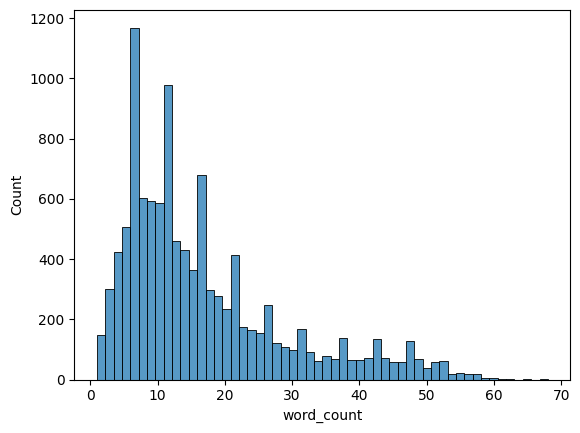

In [111]:
sns.histplot(data=db, x="word_count")

Veamos la distribución separando por clases.
En la gráfica inferior se puede observar que el número de palabras en el cuerpo
de texto no es una característica que distinga un texto misógino de uno no misógino. 
Asimismo, se confirma que la muestra de datos no esta balanceada, pues hay más datos
misóginos que no misóginos. 

<Axes: xlabel='word_count', ylabel='Count'>

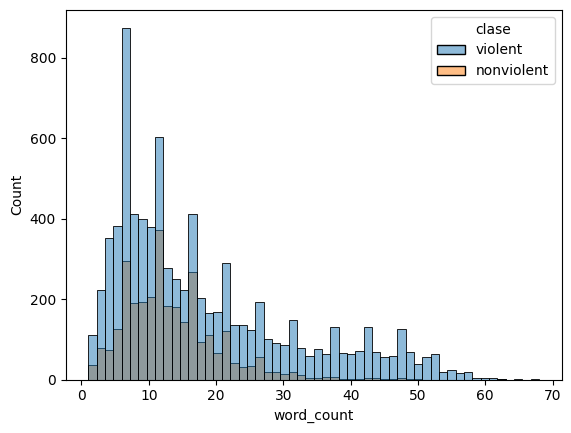

In [112]:

sns.histplot(data=db, x="word_count",hue="clase")

Análisis de frecuencia de palabras.

In [119]:
from collections import defaultdict, Counter

def build_frequency_outputs(df, top_n=60):

    corpus_tokens = [
        token
        for sentence in df["clean_tokens"].tolist()
        for token in sentence
        if not token.is_stop and not token.is_oov and not text_has_emoji(token.text)
    ]

    corpus = [token.text for token in corpus_tokens]
    corpus_lemmas = [token.lemma_ for token in corpus_tokens]

    most_freq = (
        pd.DataFrame(Counter(corpus).items(), columns=["word", "freq"])
        .sort_values("freq", ascending=False)
        .reset_index(drop=True)
    )

    most_freq_lemma = (
        pd.DataFrame(Counter(corpus_lemmas).items(), columns=["word", "freq"])
        .sort_values("freq", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    return corpus, corpus_lemmas, most_freq, most_freq_lemma

In [120]:
corpus_all, corpus_lemmas_all, most_freq_all, most_freq_lemma_all = \
    build_frequency_outputs(db)

corpus_v, corpus_lemmas_v, most_freq_v, most_freq_lemma_v = \
    build_frequency_outputs(db[db["clase"] == "violent"])

corpus_nv, corpus_lemmas_nv, most_freq_nv, most_freq_lemma_nv = \
    build_frequency_outputs(db[db["clase"] == "nonviolent"])

Comparison table

In [155]:
freq_compare = (
    most_freq_v.merge(
        most_freq_nv,
        on="word",
        how="outer",
        suffixes=("_violent", "_nonviolent")
    )
    .fillna(0)
)
freq_compare["ratio"] = (
    (freq_compare["freq_violent"] + 1) /
    (freq_compare["freq_nonviolent"] + 1)
)

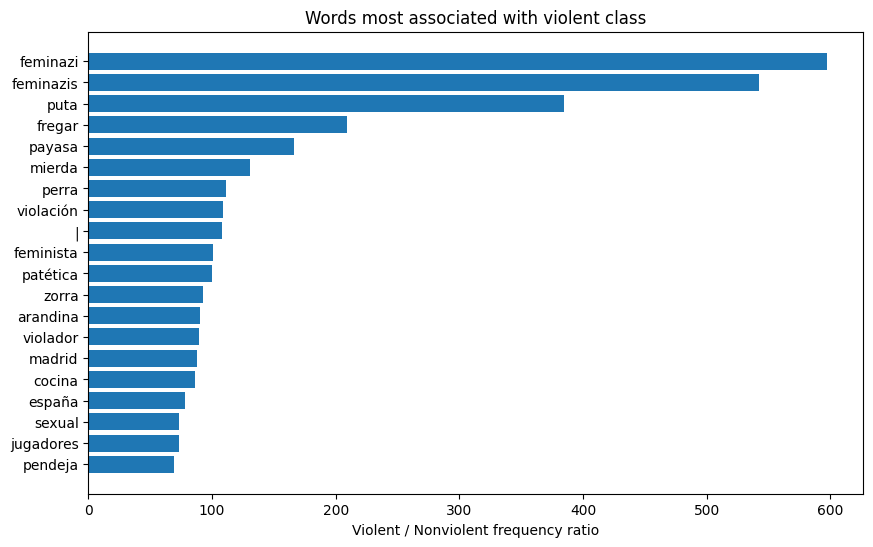

In [156]:
import matplotlib.pyplot as plt

top_words = freq_compare.sort_values("ratio", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top_words["word"], top_words["ratio"])
plt.gca().invert_yaxis()
plt.title("Words most associated with violent class")
plt.xlabel("Violent / Nonviolent frequency ratio")
plt.show()

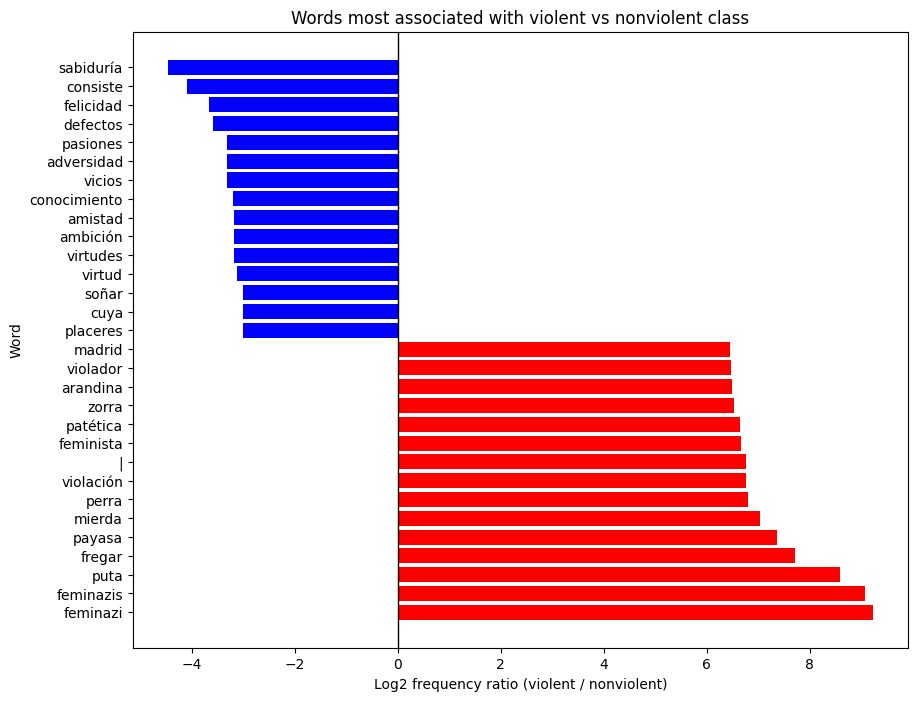

In [157]:
freq_compare["log_ratio"] = np.log2(freq_compare["ratio"])
top_violent = freq_compare.sort_values("log_ratio", ascending=False).head(15)
top_nonviolent = freq_compare.sort_values("log_ratio").head(15)

plot_df = pd.concat([top_violent, top_nonviolent]).sort_values("log_ratio", ascending=True)
plt.figure(figsize=(10,8))

colors = ["red" if x > 0 else "blue" for x in plot_df["log_ratio"]]

plt.barh(plot_df["word"], plot_df["log_ratio"], color=colors)

plt.axvline(0, color="black", linewidth=1)

plt.title("Words most associated with violent vs nonviolent class")
plt.xlabel("Log2 frequency ratio (violent / nonviolent)")
plt.ylabel("Word")

plt.gca().invert_yaxis()

plt.show()

In [164]:



corpus_v, corpus_lemmas_v, most_freq_v, most_freq_lemma_v = \
    build_frequency_outputs(db[db["clase"] == "violent"])

corpus_nv, corpus_lemmas_nv, most_freq_nv, most_freq_lemma_nv = \
    build_frequency_outputs(db[db["clase"] == "nonviolent"])

Tabla de frecuencias emojis (activate)

In [163]:
most_freq_lemma_all.head(10)

,word,freq
0,mujer,1815
1,feminazi,1135
2,hombre,847
3,puta,616
4,año,448
5,querer,429
6,vida,327
7,arandina,321
8,cosa,311
9,ver,309


In [162]:
most_freq_v.head(10)

,word,freq
0,mujer,934
1,puta,768
2,mujeres,615
3,feminazi,596
4,feminazis,541
5,arandina,449
6,años,350
7,loca,276
8,hombres,264
9,hombre,250


In [161]:
most_freq_nv.head(10)

,word,freq
0,hombre,216
1,mujer,178
2,vida,161
3,hombres,117
4,mundo,112
5,amor,110
6,cosas,91
7,mujeres,88
8,dios,74
9,tiempo,63


In [165]:
most_freq_lemma_v.head(10)

,word,freq
0,mujer,1549
1,feminazi,1135
2,puta,614
3,hombre,514
4,año,422
5,querer,325
6,arandina,318
7,feminista,287
8,ver,270
9,caso,249


In [166]:
most_freq_lemma_nv.head(10)

,word,freq
0,hombre,333
1,mujer,266
2,vida,164
3,cosa,142
4,amor,112
5,mundo,112
6,querer,104
7,pensar,84
8,tiempo,70
9,vivir,70


Tabla de palabras por frecuencia

Gráfica de barras con las palabras más usadas

<Axes: xlabel='freq', ylabel='word'>

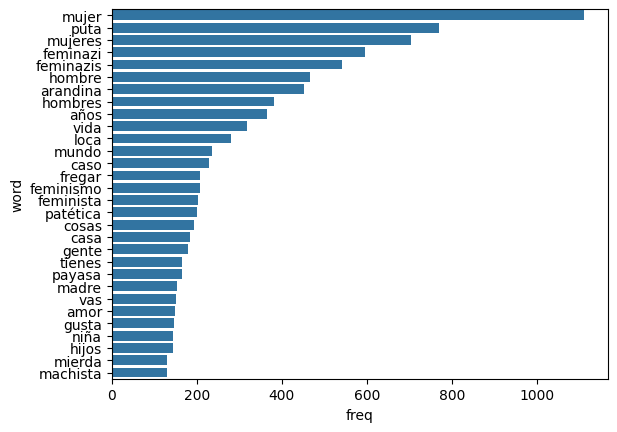

In [131]:
sns.barplot(data= most_freq_all.head(30),x="freq",y="word")

Tabla de bigramas más usados

In [135]:
bigrams_df = pd.DataFrame.from_dict(find_ngrams(corpus_v,2), orient='index').reset_index().rename(columns={"index":"bigram",0:"freq"})
bigrams_df\
.loc[bigrams_df.bigram.apply(lambda x: False if "arandina" in x else True)]\
.sort_values("freq",ascending=False).head(20)

,bigram,freq
19292,"(puta, idea)",67
5374,"(hija, puta)",58
1869,"(puta, madre)",54
11469,"(años, cárcel)",42
171,"(hijo, puta)",40
17033,"(cumbre, clima)",35
2,"(mujer, mujer)",34
5550,"(hijos, puta)",32
26227,"(agresión, sexual)",29
17581,"(cállate, puta)",29


Tabla de trigramas más usados

In [137]:

trigrams_df = pd.DataFrame.from_dict(find_ngrams(corpus_v,3), orient='index').reset_index().rename(columns={"index":"trigram",0:"freq"})
trigrams_df\
.loc[trigrams_df.trigram.apply(lambda x: False if "arandina" in x else True)]\
.sort_values("freq",ascending=False).head(20)


,trigram,freq
21656,"(tienes, puta, idea)",23
1109,"(gusta, den, duro)",14
35276,"(agresión, sexual, menor)",12
28624,"(año, revista, time)",11
9814,"(pinche, vieja, interesada)",10
48671,"(violaciones, derechos, humanos)",9
44347,"(cumbre, clima, madrid)",9
35842,"(difusión, audios, víctima)",8
18578,"(persona, año, revista)",8
9404,"(doy, paliza, escapo)",7


In [143]:

from wordcloud import WordCloud
# Read the whole text.
text = " ".join(corpus_v)
# Generate a word cloud image
wordcloud = WordCloud().generate(text)
# Display the generated image:
# the matplotlib way:
import matplotlib.pyplot as plt
# take relative word frequencies into account, lower max_font_size
wordcloud = WordCloud(background_color="white",max_words=len(text),max_font_size=40, relative_scaling=.5).generate(text)

El Dataset contiene 11717 observaciones, with 4 columnas cada uno. 

Nube de palabras más frecuente

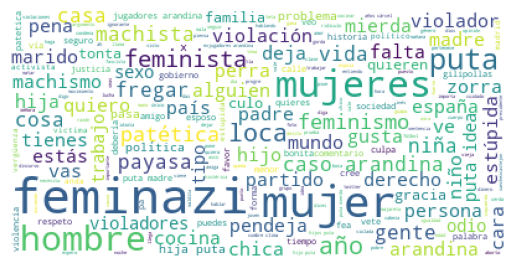

In [144]:
plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Wordcloud para los lemmas

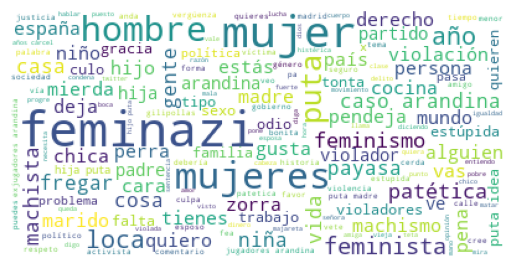

In [145]:

lemma_text = " ".join(corpus_lemmas_v)
# Generate a word cloud image
# wordcloud_lemma = WordCloud().generate(lemma_text)
# Display the generated image:
# the matplotlib way:
import matplotlib.pyplot as plt
# take relative word frequencies into account, lower max_font_size
wordcloud_lemma = WordCloud(background_color="white",max_words=len(lemma_text),max_font_size=40, relative_scaling=.5).generate(text)
plt.figure()
plt.imshow(wordcloud_lemma)
plt.axis("off")
plt.show()